# 06 — Tabular ML Results (Phase 11 — first deliverable)

Consumes the pipeline outputs from `scripts/03_run_experiment.py` and produces the **headline paper figures** for the tabular-ML side of the study.

Inputs (controlled by the `FILE_PREFIX` constant in the next cell):
- `results/predictions/{prefix}pooled_allLeads.nc` — stitched OOS predictions + truth, `(lead, time, lat, lon)`
- `results/metrics/{prefix}metrics_allLeads.csv` — pooled metrics with block-bootstrap CIs per (model, lead, evaluation_window)
- `results/logs/{prefix}fold_runs.csv` — per (fold, lead, model): best HP, val score, durations
- `results/logs/{prefix}feature_status.csv` — per (fold, lead, model, feature): importance, retained

Sections:
1. Headline skill table — every model × lead × headline metric, winter-only, with CIs + significance markers.
2. MSSS bar charts — vs climatology and vs persistence, all models × leads, with error bars.
3. ACC vs lead — line plot of anomaly correlation across leads for every model.
4. Per-cell ACC spatial maps — XGBoost vs persistence side-by-side across the 3 leads.
5. Skill lift over best baseline — table showing how much each ML model beats the *best* baseline per (lead, metric).

Figures saved to `results/figures/06_tabular_ml/`.

> **Winter-training variant.** This is a copy of `06_results_tabular_ml.ipynb` re-pointed at the outputs of the **winter-only training** sweep (v4; see `docs/SPEI3_Forecasting_Scheme_v4.md`).  All input paths read from `results/winter-training/...` and all figures are written under `results/figures/10_winter-training/...`. The notebook body is otherwise byte-identical to the original.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel.utils import save_figure, RESULTS_DIR
from droughtmodel import data as ddata
from droughtmodel import features as dfeat

# -------------------------------------------------------------------
# Switch this when the full sweep finishes:  'testOptuna_'  →  ''
# -------------------------------------------------------------------
FILE_PREFIX = ''
FIG_SUBDIR = '10_winter-training/06_tabular_ml'

PREDS_PATH  = RESULTS_DIR / 'winter-training' / 'predictions' / f'{FILE_PREFIX}pooled_allLeads.nc'
METRICS_PATH = RESULTS_DIR / 'winter-training' / 'metrics'    / f'{FILE_PREFIX}metrics_allLeads.csv'
FOLD_RUNS_PATH = RESULTS_DIR / 'winter-training' / 'logs'     / f'{FILE_PREFIX}fold_runs.csv'
FEAT_STATUS_PATH = RESULTS_DIR / 'winter-training' / 'logs'   / f'{FILE_PREFIX}feature_status.csv'

# Display order: baselines first, then linear, then trees
MODEL_ORDER = ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
MODEL_COLORS = dict(zip(MODEL_ORDER, sns.color_palette('tab10', n_colors=len(MODEL_ORDER))))
BASELINE_NAMES = {'climatology', 'persistence', 'ar'}

print(f'Reading from prefix: {FILE_PREFIX!r}')
for p in [PREDS_PATH, METRICS_PATH, FOLD_RUNS_PATH, FEAT_STATUS_PATH]:
    print(f'  {p.relative_to(ROOT)}  {"✓" if p.exists() else "✗ MISSING"}')

Reading from prefix: ''
  results/winter-training/predictions/pooled_allLeads.nc  ✓
  results/winter-training/metrics/metrics_allLeads.csv  ✓
  results/winter-training/logs/fold_runs.csv  ✓
  results/winter-training/logs/feature_status.csv  ✓


In [2]:
# Load everything
ds_preds = xr.open_dataset(PREDS_PATH)
metrics_df = pd.read_csv(METRICS_PATH)
fold_runs = pd.read_csv(FOLD_RUNS_PATH)
feat_status = pd.read_csv(FEAT_STATUS_PATH)

# Restrict the displayed/iterated model set to what's actually in this run
models_present = [m for m in MODEL_ORDER if m in metrics_df['model'].unique()]
leads = sorted(metrics_df['lead'].unique())

print(f'Predictions dataset:  {dict(ds_preds.sizes)}')
print(f'Metrics rows:         {len(metrics_df)} ({metrics_df["evaluation_window"].unique()})')
print(f'Fold runs rows:       {len(fold_runs)}')
print(f'Feature status rows:  {len(feat_status)}')
print(f'Models present:       {models_present}')
print(f'Leads:                {leads}')

Predictions dataset:  {'lead': 3, 'time': 300, 'lat': 64, 'lon': 64}
Metrics rows:         1944 (<ArrowStringArray>
['winter_only', 'all_months']
Length: 2, dtype: str)
Fold runs rows:       135
Feature status rows:  5409
Models present:       ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
Leads:                [np.int64(1), np.int64(3), np.int64(6)]


## 1. Headline skill table (winter-only)

Per (model × lead) for the six headline metrics. Each cell is `value` followed by `*` when the 95 % block-bootstrap CI excludes 0 (only meaningful for higher-is-better metrics: `pearson_r`, `acc`, `msss_vs_climatology`, `msss_vs_persistence`).

Climatology's `acc` shows as `NaN` by construction — see notebook 05 §6 notes for the explanation (a zero-variance-anomaly forecast has no ACC).

The exported CSV is the same shape, ready to copy into LaTeX / Overleaf.

In [3]:
HIGHER_IS_BETTER = {'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence'}
HEADLINE_METRICS = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']

def _significant(row) -> bool:
    if row['metric'] not in HIGHER_IS_BETTER or pd.isna(row['ci_lower']) or pd.isna(row['ci_upper']):
        return False
    return bool(row['ci_lower'] > 0 or row['ci_upper'] < 0)

def _format_value(row) -> str:
    v = row['value']
    if pd.isna(v):
        return 'NaN'
    return f'{v:.2f}' + ('*' if _significant(row) else '')

winter = metrics_df.query("evaluation_window == 'winter_only' and fold == 'pooled'").copy()  # filter pooled rows only — per-fold rows would create duplicate (model,lead,metric) keys for the pivot below
winter['formatted'] = winter.apply(_format_value, axis=1)

table = (
    winter
    .pivot(index=['model', 'lead'], columns='metric', values='formatted')
    .loc[[(m, L) for m in models_present for L in leads]]
    [HEADLINE_METRICS]
)
table.columns.name = None

# Save the LaTeX-ready CSV
out = RESULTS_DIR / 'winter-training' / 'metrics' / f'{FILE_PREFIX}headline_table_winter.csv'
table.to_csv(out)
print(f'Saved → {out.relative_to(ROOT)}')
print('* = 95% bootstrap CI excludes 0 (higher-is-better metrics only)\n')

table

Saved → results/winter-training/metrics/headline_table_winter.csv
* = 95% bootstrap CI excludes 0 (higher-is-better metrics only)



mae  rmse pearson_r    acc msss_vs_climatology  \
model       lead                                                    
climatology 1     0.83  0.99    -0.12*    NaN                0.00   
            3     0.83  1.00    -0.10*    NaN                0.00   
            6     0.87  1.03    -0.20*    NaN                0.00   
persistence 1     0.55  0.71     0.72*  0.72*               0.49*   
            3     1.08  1.32      0.02   0.02              -0.74*   
            6     1.00  1.27      0.14   0.15              -0.50*   
ar          1     0.51  0.62     0.77*  0.77*               0.61*   
            3     0.82  0.99     -0.04   0.10               0.03*   
            6     0.85  1.01      0.04  0.28*               0.04*   
ols         1     0.45  0.55     0.81*  0.81*               0.69*   
            3     0.89  1.07     -0.13  -0.10              -0.15*   
            6     1.20  1.45     -0.01   0.04              -0.97*   
ridge       1     0.44  0.55     0.82*  0.82*               0.70*   
            3     0.86  1.04     -0.14  -0.10              -0.08*   
            6     1.02  1.23     -0.03   0.02              -0.42*   
lasso       1     0.44  0.54     0.82*  0.82*               0.70*   
            3     0.82  0.99     -0.07   0.04                0.02   
            6     0.85  1.02     0.20*  0.29*               0.03*   
elasticnet  1     0.45  0.54     0.82*  0.82*               0.70*   
            3     0.82  0.99     -0.07   0.03                0.02   
            6     0.85  1.02     0.20*  0.29*               0.03*   
rf          1     0.52  0.63     0.75*  0.76*               0.60*   
            3     0.84  1.02      0.08   0.09               -0.04   
            6     0.85  1.02      0.00   0.11                0.04   
xgboost     1     0.50  0.61     0.77*  0.78*               0.63*   
            3     0.82  0.99      0.11  0.15*                0.02   
            6     0.91  1.12     -0.09  -0.04               -0.17   

                 msss_vs_persistence  
model       lead                      
climatology 1                 -0.96*  
            3                  0.43*  
            6                  0.33*  
persistence 1                   0.00  
            3                   0.00  
            6                   0.00  
ar          1                  0.23*  
            3                  0.44*  
            6                  0.36*  
ols         1                  0.39*  
            3                  0.34*  
            6                  -0.32  
ridge       1                  0.41*  
            3                  0.38*  
            6                   0.05  
lasso       1                  0.42*  
            3                  0.44*  
            6                  0.36*  
elasticnet  1                  0.41*  
            3                  0.44*  
            6                  0.36*  
rf          1                  0.21*  
            3                  0.40*  
            6                  0.36*  
xgboost     1                  0.27*  
            3                  0.44*  
            6                   0.22

## 2. MSSS bar charts — vs climatology and vs persistence

Positive bars beat the reference. Grouped by lead, coloured by model. Error bars are the 95 % block-bootstrap CI.

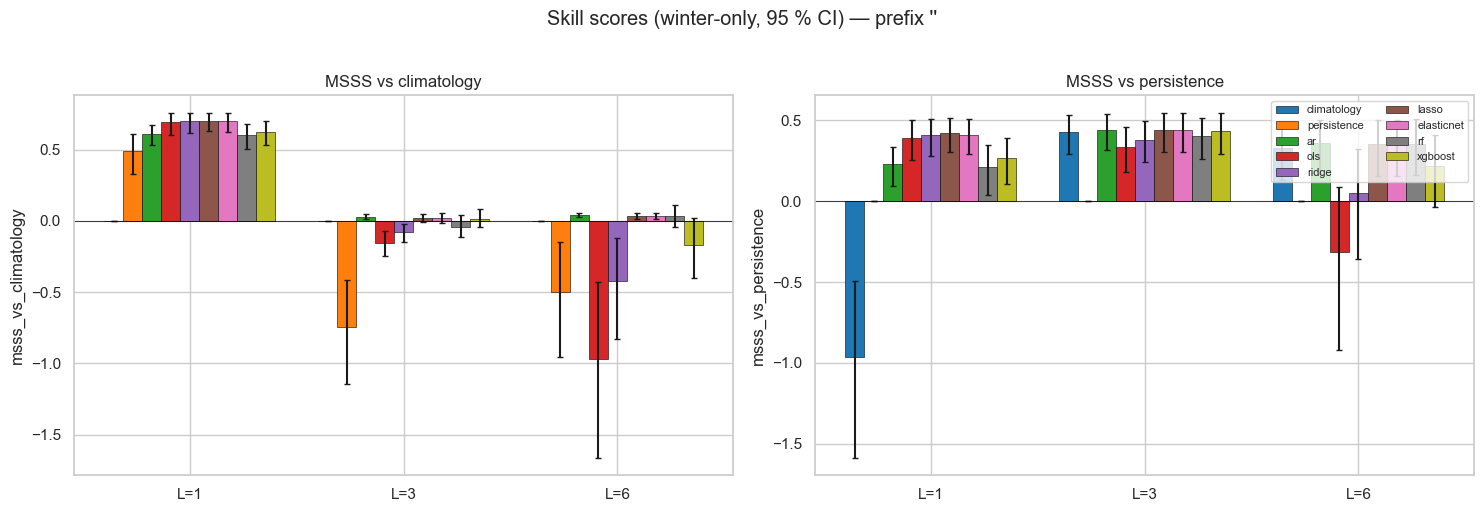

In [4]:
def _bar(ax, metric_name, title):
    sub = winter[winter['metric'] == metric_name].copy()
    sub['model'] = pd.Categorical(sub['model'], categories=models_present, ordered=True)
    sub = sub.sort_values(['lead', 'model'])
    n_models = len(models_present)
    width = 0.8 / n_models
    x = np.arange(len(leads))
    for i, mdl in enumerate(models_present):
        s = sub[sub['model'] == mdl].set_index('lead').reindex(leads)
        yerr_lo = s['value'].values - s['ci_lower'].values
        yerr_hi = s['ci_upper'].values - s['value'].values
        ax.bar(
            x + (i - n_models / 2 + 0.5) * width, s['value'].values,
            yerr=np.vstack([yerr_lo, yerr_hi]),
            capsize=2.5, width=width, edgecolor='black', linewidth=0.4,
            label=mdl, color=MODEL_COLORS.get(mdl, None),
        )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'L={L}' for L in leads])
    ax.set_ylabel(metric_name)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
_bar(axes[0], 'msss_vs_climatology', 'MSSS vs climatology')
_bar(axes[1], 'msss_vs_persistence', 'MSSS vs persistence')
axes[1].legend(loc='upper right', fontsize=8, ncol=2)
plt.suptitle(f'Skill scores (winter-only, 95 % CI) — prefix {FILE_PREFIX!r}', y=1.02)
plt.tight_layout()
save_figure(fig, 'msss_bars', subdir=FIG_SUBDIR)
plt.show()

## 3. ACC vs lead

Anomaly Correlation Coefficient across leads for every model. Climatology is omitted (zero-variance forecast → ACC undefined; see notebook 05 §6).

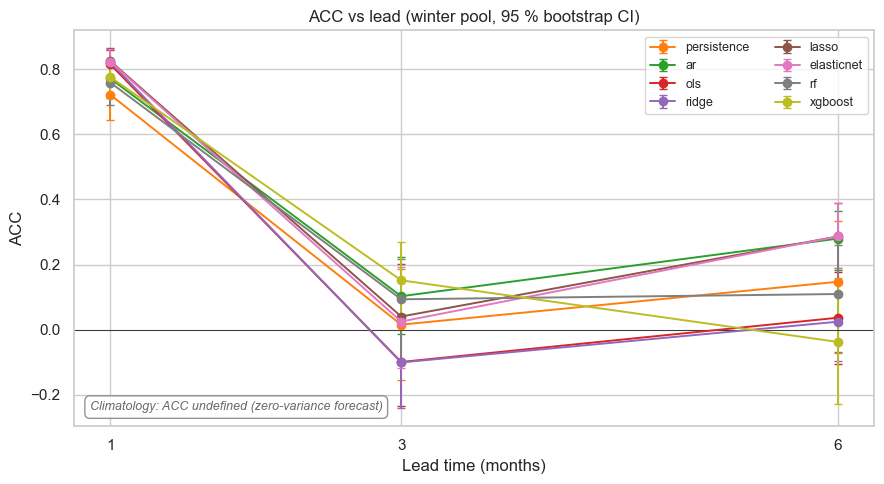

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
acc = winter[winter['metric'] == 'acc']
for mdl in models_present:
    sub = acc[acc['model'] == mdl].sort_values('lead')
    if sub['value'].isna().all():
        continue  # climatology
    yerr_lo = sub['value'].values - sub['ci_lower'].values
    yerr_hi = sub['ci_upper'].values - sub['value'].values
    ax.errorbar(
        sub['lead'], sub['value'],
        yerr=[yerr_lo, yerr_hi],
        marker='o', capsize=3, label=mdl, linewidth=1.4,
        color=MODEL_COLORS.get(mdl, None),
    )
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(leads)
ax.set_xlabel('Lead time (months)')
ax.set_ylabel('ACC')
ax.set_title('ACC vs lead (winter pool, 95 % bootstrap CI)')
ax.legend(loc='best', fontsize=9, ncol=2)
ax.text(
    0.02, 0.04,
    'Climatology: ACC undefined (zero-variance forecast)',
    transform=ax.transAxes, fontsize=9, style='italic', color='dimgray',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.4'),
)
plt.tight_layout()
save_figure(fig, 'acc_vs_lead', subdir=FIG_SUBDIR)
plt.show()

## 4. Per-cell ACC spatial maps — XGBoost vs Persistence

Anomaly-correlation skill per Morocco cell. Rows = model; columns = lead. Skill is computed on the winter pool only (Nov-Feb target months).

Side-by-side rows let you see where the ML model adds skill over the persistence baseline (red regions are positive ACC = the model tracks anomaly direction; blue = anti-correlated).

If the comparison is uninteresting (XGBoost has weak ACC at this `n_trials` budget), don't read too much into it — the Optuna budget in the smoke is 5 trials per fold-lead. The production sweep at 40 trials should give much sharper trees.

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18955/1672340251.py:15: RuntimeWarning: Mean of empty slice
  pa_m = np.nanmean(pa, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18955/1672340251.py:16: RuntimeWarning: Mean of empty slice
  ta_m = np.nanmean(ta, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18955/1672340251.py:17: RuntimeWarning: Mean of empty slice
  num = np.nanmean((pa - pa_m) * (ta - ta_m), axis=0)
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18955/1672340251.py:15: RuntimeWarning: Mean of empty slice
  pa_m = np.nanmean(pa, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18955/1672340251.py:16: RuntimeWarning: Mean of empty slice
  ta_m = np.nanmean(ta, axis=0)
/var/fo

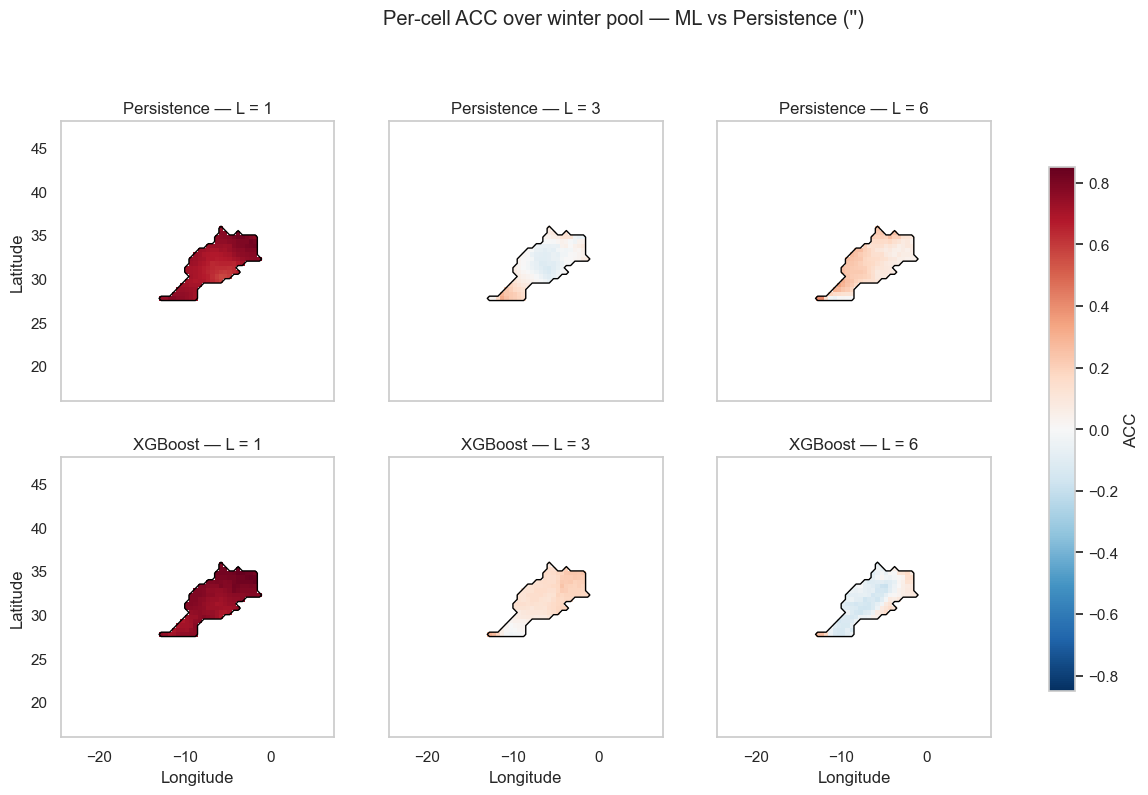

Morocco-mean per-cell ACC:
  persistence  L=1: mean = +0.715
  xgboost      L=1: mean = +0.767
  persistence  L=3: mean = +0.015
  xgboost      L=3: mean = +0.139
  persistence  L=6: mean = +0.154
  xgboost      L=6: mean = -0.044


In [6]:
# Load Morocco mask from features.py (consistent with the pipeline)
data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
raw_datasets = ddata.load_all(data_cfg)
template = dfeat.gather_predictor('spei3', raw_datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')

def per_cell_acc(pred_arr, truth_arr, clim_arr, winter_mask, mask):
    """Per-cell ACC over winter months. Returns (lat, lon) array, NaN outside Morocco."""
    yp = pred_arr[winter_mask]
    yt = truth_arr[winter_mask]
    yc = clim_arr[winter_mask]
    pa = yp - yc
    ta = yt - yc
    pa_m = np.nanmean(pa, axis=0)
    ta_m = np.nanmean(ta, axis=0)
    num = np.nanmean((pa - pa_m) * (ta - ta_m), axis=0)
    pa_s = np.nanstd(pa, axis=0)
    ta_s = np.nanstd(ta, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        a = num / (pa_s * ta_s)
    a[~mask.values] = np.nan
    return a

ROW_MODELS = [('persistence', 'Persistence'), ('xgboost', 'XGBoost')]
ROW_MODELS = [(m, lbl) for m, lbl in ROW_MODELS if m in models_present]

time_idx = pd.DatetimeIndex(ds_preds['time'].values)
acc_grids = {}
for L in leads:
    winter_mask = np.isin(time_idx.month, [11, 12, 1, 2])
    clim = ds_preds['pred_climatology'].sel(lead=L).values
    truth = ds_preds['truth'].sel(lead=L).values
    for mdl, _ in ROW_MODELS:
        pred = ds_preds[f'pred_{mdl}'].sel(lead=L).values
        acc_grids[(mdl, L)] = per_cell_acc(pred, truth, clim, winter_mask, morocco_mask)

vmax = float(np.nanmax(np.abs(list(acc_grids.values())))) or 1.0

fig, axes = plt.subplots(len(ROW_MODELS), len(leads), figsize=(5 * len(leads), 4 * len(ROW_MODELS)), sharex=True, sharey=True)
if len(ROW_MODELS) == 1:
    axes = axes[np.newaxis, :]
im = None
for r, (mdl, label) in enumerate(ROW_MODELS):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        da = xr.DataArray(
            acc_grids[(mdl, L)], dims=('lat', 'lon'),
            coords={'lat': morocco_mask['lat'], 'lon': morocco_mask['lon']},
        )
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax, add_colorbar=False)
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.0, add_colorbar=False)
        ax.set_title(f'{label} — L = {L}')
        ax.set_xlabel('Longitude' if r == len(ROW_MODELS) - 1 else '')
        ax.set_ylabel('Latitude' if c == 0 else '')

fig.colorbar(im, ax=axes.ravel().tolist(), label='ACC', shrink=0.85)
fig.suptitle(f'Per-cell ACC over winter pool — ML vs Persistence ({FILE_PREFIX!r})', y=1.02)
save_figure(fig, 'per_cell_acc_ml_vs_baseline', subdir=FIG_SUBDIR)
plt.show()

print('Morocco-mean per-cell ACC:')
for (mdl, L), arr in acc_grids.items():
    print(f'  {mdl:12s} L={L}: mean = {float(np.nanmean(arr)):+.3f}')

## 5. Skill lift over the best baseline

Per (model × lead), the table shows the lift (improvement) of each ML model over the **best-performing baseline** for that metric and lead. A positive lift means the ML model beats the strongest baseline; negative means it's worse than the best baseline.

In [7]:
ML_MODELS = [m for m in models_present if m not in BASELINE_NAMES]
LIFT_METRICS = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology']
# For MAE/RMSE: lower is better → lift = baseline_best - model
# For others:   higher is better → lift = model - baseline_best
LOWER_IS_BETTER = {'mae', 'rmse'}

rows = []
for L in leads:
    for metric in LIFT_METRICS:
        baseline_vals = winter.query(
            "model in @BASELINE_NAMES and lead == @L and metric == @metric"
        )['value'].dropna()
        if baseline_vals.empty:
            continue
        if metric in LOWER_IS_BETTER:
            baseline_best = baseline_vals.min()
        else:
            baseline_best = baseline_vals.max()
        for mdl in ML_MODELS:
            val = winter.query("model == @mdl and lead == @L and metric == @metric")['value']
            if val.empty or pd.isna(val.iloc[0]):
                continue
            v = val.iloc[0]
            if metric in LOWER_IS_BETTER:
                lift = baseline_best - v   # positive when ML has lower error
            else:
                lift = v - baseline_best
            rows.append({'model': mdl, 'lead': L, 'metric': metric, 'lift': lift})

lift_df = pd.DataFrame(rows)
lift_table = lift_df.pivot(index=['model', 'lead'], columns='metric', values='lift')[LIFT_METRICS].round(3)
lift_table.columns.name = None

out = RESULTS_DIR / 'winter-training' / 'metrics' / f'{FILE_PREFIX}lift_over_best_baseline.csv'
lift_table.to_csv(out)
print(f'Saved → {out.relative_to(ROOT)}')
print('Positive = ML model beats the best baseline; negative = best baseline still wins.\n')

lift_table

Saved → results/winter-training/metrics/lift_over_best_baseline.csv
Positive = ML model beats the best baseline; negative = best baseline still wins.



mae   rmse  pearson_r    acc  msss_vs_climatology
model      lead                                                     
elasticnet 1     0.062  0.078      0.053  0.051                0.093
           3    -0.002 -0.003     -0.086 -0.078               -0.006
           6    -0.004 -0.003      0.062  0.007               -0.007
lasso      1     0.067  0.082      0.055  0.054                0.097
           3    -0.003 -0.003     -0.091 -0.062               -0.007
           6    -0.004 -0.003      0.062  0.007               -0.007
ols        1     0.063  0.071      0.045  0.043                0.084
           3    -0.072 -0.088     -0.152 -0.202               -0.182
           6    -0.354 -0.439     -0.147 -0.243               -1.011
rf         1    -0.010 -0.006     -0.012 -0.012               -0.007
           3    -0.025 -0.034      0.059 -0.009               -0.069
           6    -0.002 -0.003     -0.135 -0.170               -0.006
ridge      1     0.064  0.077      0.051  0.050                0.091
           3    -0.043 -0.053     -0.154 -0.203               -0.108
           6    -0.169 -0.220     -0.161 -0.255               -0.462
xgboost    1     0.009  0.016      0.006  0.004                0.020
           3    -0.000 -0.006      0.092  0.049               -0.013
           6    -0.060 -0.106     -0.221 -0.317               -0.211

## Notes

**What's in this notebook**: the five tables/figures above are the paper-facing tabular-ML deliverable. They consume only the files written by `ExperimentRunner` — no model is re-fit here.

**To swap from smoke output to the production sweep**:
- Change `FILE_PREFIX = 'testOptuna_'` to `''` in the second cell.
- Re-run all cells. The exported CSVs and figures will use the production data.

**Caveats on the current smoke data**:
- RF and XGBoost ran with `n_trials=5` (Optuna budget) per fold-lead — that is *not* enough to land good HPs on a 72/144-cell categorical space. Their skill numbers in the smoke are pessimistic.
- The production sweep at `n_trials=40` should give substantially tighter tree-model results.
- Linear models in the smoke also use shrunk grids (3/4/6 combos) vs the production 13/13/35.

**Next notebooks** (Phase 11 follow-ups):
- `07_spatial_skill_maps.ipynb` — per-cell MSSS / HSS maps for every (model, lead), plus difference maps showing where ML adds value over each baseline.
- `08_feature_importance.ipynb` — Lasso / ElasticNet retained-feature stability across folds; permutation importance for RF; TreeSHAP for XGBoost.
- `09_paper_figures.ipynb` — final publication-ready exports with consistent style.